# Protein Cofactor Binary Classification

Trains binary classifiers to predict which cofactors a protein uses based on its sequence.
Uses ESM2 protein language model for embeddings and logistic regression for classification.
One classifier per cofactor - each predicts presence/absence independently.
Automatically detects cofactors from CSV column headers - works with any cofactor set.

In [7]:
# Install required packages for ESM2 embeddings and machine learning
%pip install tqdm torch torchvision fair-esm scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Import libraries for data processing, embeddings, and machine learning

import os
import math
import json
import random
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import esm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    top_k_accuracy_score
)
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Set random seeds for reproducibility and configure device (GPU/CPU)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


Input CSV format: protein sequences with binary cofactor labels.
Each cofactor column has 1 if protein uses it, 0 otherwise.
Processing converts binary labels to ideal_cofactor target variable.
Cofactor columns are automatically detected from CSV headers.

In [10]:
# Load CSV file containing protein sequences and binary cofactor labels

data_path = r"C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\ncbi_enzyme_cofactor_data.csv"
df_raw = pd.read_csv(data_path)

# Automatically detect cofactor columns (exclude non-cofactor columns)
exclude_cols = {'header', 'sequence', 'protein_id'}
cofactor_cols = [col for col in df_raw.columns if col not in exclude_cols]

print("Raw data shape:", df_raw.shape)
print("\nFirst few rows:")
print(df_raw.head())
print("\nColumn names:", df_raw.columns.tolist())
print(f"\nDetected cofactor columns: {cofactor_cols}")
print("\nCofactor distribution:")
print(df_raw[cofactor_cols].sum())

Raw data shape: (2241, 7)

First few rows:
                                              header  \
0  NP_013752.1 copper chaperone CCS1 [Saccharomyc...   
1       pdb|1PF3|A Chain A, Blue copper oxidase cueO   
2  WP_415607860.1 copper homeostasis protein CutC...   
3  WP_289940195.1 copper homeostasis protein CutC...   
4      CAN5492343.1 copper oxidase [soil metagenome]   

                                            sequence  Cu  ATP  B12  CoA  NAD  
0  MTTNDTYEATYAIPMHCENCVNDIKACLKNVPGINSLNFDIEQQIM...   1    0    0    0    0  
1  AERPTLPIPDLLTTDARNRIQLTIGAGQSTFGGKTATTWGYNGNLL...   1    0    1    1    1  
2  MTIKIKEAAVDSADRAQEMIARGANRIELNARLDLGGITPDTRTII...   1    0    0    0    0  
3  MARRLGSERRTVTTAADPASLAEKSSTRARALVEICVDDLAGVLAA...   1    0    0    0    0  
4  MRAAGATMIGAAAVSRAAAASLPEAETRSSPAMRPPPSPPNGRPFH...   1    0    0    0    0  

Column names: ['header', 'sequence', 'Cu', 'ATP', 'B12', 'CoA', 'NAD']

Detected cofactor columns: ['Cu', 'ATP', 'B12', 'CoA', 'NAD']

Cofactor d

In [11]:
# Process binary cofactor labels: rename columns and create ideal_cofactor target
# Converts binary columns (Cu=1, Fe=0, etc.) to single target variable

df_raw = df_raw.rename(columns={'header': 'protein_id'})

# Use the dynamically detected cofactor columns from previous cell
# cofactor_cols is already defined in the previous cell

def determine_ideal_cofactor(row):
    active_cofactors = [col for col in cofactor_cols if row[col] == 1]
    
    if len(active_cofactors) == 0:
        return 'None'
    elif len(active_cofactors) == 1:
        return active_cofactors[0]
    else:
        return '_'.join(active_cofactors)

df_raw['ideal_cofactor'] = df_raw.apply(determine_ideal_cofactor, axis=1)

print("\nIdeal cofactor distribution:")
print(df_raw['ideal_cofactor'].value_counts())

print(f"\nRows with no active cofactors: {(df_raw['ideal_cofactor'] == 'None').sum()}")

# Dynamically create activity columns for each cofactor
for cofactor in cofactor_cols:
    activity_col = f'activity_{cofactor.lower()}'
    df_raw[activity_col] = df_raw[cofactor]

# Build column list dynamically
activity_cols = [f'activity_{cf.lower()}' for cf in cofactor_cols]
df = df_raw[['protein_id', 'sequence', 'ideal_cofactor'] + activity_cols].copy()

print("\nProcessed dataset shape:", df.shape)
print("\nFirst few rows of processed data:")
print(df.head())


Ideal cofactor distribution:
ideal_cofactor
ATP               498
NAD               491
B12               485
CoA               446
Cu                319
Cu_B12_CoA_NAD      1
Cu_CoA              1
Name: count, dtype: int64

Rows with no active cofactors: 0

Processed dataset shape: (2241, 8)

First few rows of processed data:
                                          protein_id  \
0  NP_013752.1 copper chaperone CCS1 [Saccharomyc...   
1       pdb|1PF3|A Chain A, Blue copper oxidase cueO   
2  WP_415607860.1 copper homeostasis protein CutC...   
3  WP_289940195.1 copper homeostasis protein CutC...   
4      CAN5492343.1 copper oxidase [soil metagenome]   

                                            sequence  ideal_cofactor  \
0  MTTNDTYEATYAIPMHCENCVNDIKACLKNVPGINSLNFDIEQQIM...              Cu   
1  AERPTLPIPDLLTTDARNRIQLTIGAGQSTFGGKTATTWGYNGNLL...  Cu_B12_CoA_NAD   
2  MTIKIKEAAVDSADRAQEMIARGANRIELNARLDLGGITPDTRTII...              Cu   
3  MARRLGSERRTVTTAADPASLAEKSSTRARALVEICVDDLAG

In [71]:
# Validate that dataset has required columns and check class distribution

required_cols = ["protein_id", "sequence", "ideal_cofactor"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Dataset shape:", df.shape)
print("\nIdeal cofactor distribution:")
print(df["ideal_cofactor"].value_counts())

print(f"\nFinal dataset shape: {df.shape}")

Dataset shape: (2241, 8)

Ideal cofactor distribution:
ideal_cofactor
ATP               498
NAD               491
B12               485
CoA               446
Cu                319
Cu_B12_CoA_NAD      1
Cu_CoA              1
Name: count, dtype: int64

Final dataset shape: (2241, 8)


In [13]:
# Optional filtering: remove proteins with no active cofactors or multi-cofactor proteins
# Set flags to control dataset composition

REMOVE_NONE_COFACTORS = False

if REMOVE_NONE_COFACTORS:
    df_before = df.shape[0]
    df = df[df['ideal_cofactor'] != 'None'].copy()
    df.reset_index(drop=True, inplace=True)
    print(f"Removed {df_before - df.shape[0]} proteins with no active cofactors")
    print(f"New dataset shape: {df.shape}")
    print("\nNew cofactor distribution:")
    print(df["ideal_cofactor"].value_counts())
else:
    print("Keeping all data including negative examples (proteins with no active cofactors)")
    print(f"Dataset shape: {df.shape}")
    print("\nCofactor distribution (including 'None' for negative examples):")
    print(df["ideal_cofactor"].value_counts())

Keeping all data including negative examples (proteins with no active cofactors)
Dataset shape: (2241, 8)

Cofactor distribution (including 'None' for negative examples):
ideal_cofactor
ATP               498
NAD               491
B12               485
CoA               446
Cu                319
Cu_B12_CoA_NAD      1
Cu_CoA              1
Name: count, dtype: int64


In [14]:
# Clean protein sequences: remove invalid characters, ensure valid amino acids only

VALID_AA = set(list("ACDEFGHIKLMNPQRSTVWYUXBZJO"))

def clean_sequence(seq: str) -> str:
    seq = str(seq).strip().upper()
    seq = seq.replace(" ", "")
    seq = "".join([aa for aa in seq if aa in VALID_AA])
    return seq

df["sequence"] = df["sequence"].apply(clean_sequence)

df = df[df["sequence"].str.len() >= 20].copy()
df.reset_index(drop=True, inplace=True)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (2241, 8)


Note: Using classical ML classifier (Logistic Regression) first before trying deep learning.
Works well on small datasets, easier to debug, and less prone to overfitting.
Sequence embeddings from ESM2 provide biological context.

In [15]:
# Load pretrained ESM2 model for generating protein sequence embeddings
# Using smaller 8M parameter model for faster processing

model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()

model = model.to(DEVICE)
model.eval()

print("Loaded ESM model.")

Loaded ESM model.


In [16]:
# Define function to generate fixed-length embeddings from protein sequences
# Uses mean pooling over residue embeddings from ESM2 model

@torch.no_grad()
def embed_sequences_esm(
    sequences: List[str],
    ids: Optional[List[str]] = None,
    batch_size: int = 8,
    repr_layer: int = 6,
    truncate_len: int = 1022
) -> np.ndarray:
    if ids is None:
        ids = [f"seq_{i}" for i in range(len(sequences))]

    data = [(ids[i], sequences[i][:truncate_len]) for i in range(len(sequences))]
    all_embeddings = []

    for start in tqdm(range(0, len(data), batch_size), desc="Embedding sequences"):
        batch = data[start:start+batch_size]
        labels, strs, tokens = batch_converter(batch)
        tokens = tokens.to(DEVICE)

        out = model(tokens, repr_layers=[repr_layer], return_contacts=False)
        token_representations = out["representations"][repr_layer]

        for i, seq in enumerate(strs):
            seq_len = len(seq)
            residue_embeddings = token_representations[i, 1:seq_len+1]
            pooled = residue_embeddings.mean(0).cpu().numpy()
            all_embeddings.append(pooled)

    return np.vstack(all_embeddings)

In [17]:
# Generate embeddings for all protein sequences in the dataset
# Results in 320-dimensional vector for each protein

protein_ids = df["protein_id"].tolist()
sequences = df["sequence"].tolist()

X_seq = embed_sequences_esm(
    sequences=sequences,
    ids=protein_ids,
    batch_size=4,
    repr_layer=6
)

print("Sequence embedding matrix shape:", X_seq.shape)

Embedding sequences: 100%|██████████| 561/561 [08:03<00:00,  1.16it/s]

Sequence embedding matrix shape: (2241, 320)


## Binary Classification Approach

Train separate binary classifiers for each cofactor:
- One model per cofactor: Does this protein use [cofactor]? (Yes/No)
- Number of classifiers = number of cofactors in your CSV

Data leakage prevention:
- Only use sequence embeddings as input features
- Binary labels from CSV are targets (what we predict), not input features
- No activity columns passed to models

Advantages:
- Balanced classes for each classifier
- Can handle multi-cofactor proteins naturally
- Realistic predictions based only on sequence patterns
- Automatically adapts to any cofactor set in CSV headers

In [57]:
# Create binary labels for each cofactor from original CSV columns

print("=== CREATING BINARY LABELS (NO LEAKAGE) ===\n")

# Use the dynamically detected cofactor columns
cofactor_names = cofactor_cols

binary_labels = {}
for cofactor in cofactor_names:
    binary_labels[cofactor] = df_raw.loc[df.index, cofactor].values
    
print("Binary label distribution:")
for cofactor in cofactor_names:
    n_positive = binary_labels[cofactor].sum()
    n_negative = len(binary_labels[cofactor]) - n_positive
    print(f"  {cofactor}: {n_positive} positive, {n_negative} negative")

print(f"\nLabels created from original binary columns ({', '.join(cofactor_names)})")
print("These tell us which cofactors each protein actually uses")

=== CREATING BINARY LABELS (NO LEAKAGE) ===

Binary label distribution:
  Cu: 321 positive, 1920 negative
  ATP: 498 positive, 1743 negative
  B12: 486 positive, 1755 negative
  CoA: 448 positive, 1793 negative
  NAD: 492 positive, 1749 negative

Labels created from original binary columns (Cu, ATP, B12, CoA, NAD)
These tell us which cofactors each protein actually uses


In [58]:
# Train binary classifiers using ONLY sequence embeddings (no activity features)
# One classifier per cofactor to prevent data leakage

print("=== TRAINING BINARY CLASSIFIERS ===\n")
print("DATA LEAKAGE PREVENTION:")
print("  - Using ONLY X_seq (sequence embeddings)")
print("  - Shape:", X_seq.shape)
print("  - NO activity columns included")
print("  - NO numeric features that encode the answer\n")

binary_classifiers = {}
binary_results = {}

for cofactor in cofactor_names:
    print(f"Training {cofactor} classifier...")
    
    y_binary = binary_labels[cofactor]
    
    X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
        X_seq,
        y_binary,
        test_size=0.8,
        random_state=SEED,
        stratify=y_binary if len(np.unique(y_binary)) > 1 and min(np.bincount(y_binary)) >= 2 else None
    )
    
    clf_binary = LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=SEED
    )
    clf_binary.fit(X_train_bin, y_train_bin)
    
    y_pred_bin = clf_binary.predict(X_test_bin)
    y_proba_bin = clf_binary.predict_proba(X_test_bin)
    
    accuracy = accuracy_score(y_test_bin, y_pred_bin)
    f1 = f1_score(y_test_bin, y_pred_bin, average='binary', zero_division=0)
    
    binary_classifiers[cofactor] = clf_binary
    binary_results[cofactor] = {
        'accuracy': accuracy,
        'f1': f1,
        'y_test': y_test_bin,
        'y_pred': y_pred_bin,
        'y_proba': y_proba_bin
    }
    
    print(f"  {cofactor}: Accuracy={accuracy:.3f}, F1={f1:.3f}")

print("\nAll classifiers trained using ONLY sequence embeddings")

=== TRAINING BINARY CLASSIFIERS ===

DATA LEAKAGE PREVENTION:
  - Using ONLY X_seq (sequence embeddings)
  - Shape: (2241, 320)
  - NO activity columns included
  - NO numeric features that encode the answer

Training Cu classifier...
  Cu: Accuracy=0.974, F1=0.911
Training ATP classifier...
  ATP: Accuracy=0.988, F1=0.972
Training B12 classifier...
  B12: Accuracy=0.950, F1=0.892
Training CoA classifier...
  CoA: Accuracy=0.953, F1=0.890
Training NAD classifier...
  NAD: Accuracy=0.986, F1=0.968

All classifiers trained using ONLY sequence embeddings


In [59]:
# Detailed evaluation metrics for each binary classifier

print("=== DETAILED PERFORMANCE BY COFACTOR ===\n")

for cofactor in cofactor_names:
    results = binary_results[cofactor]
    print(f"\n{cofactor} Classifier:")
    print("=" * 40)
    print(classification_report(
        results['y_test'], 
        results['y_pred'],
        target_names=['No ' + cofactor, 'Has ' + cofactor],
        zero_division=0
    ))
    
    cm_binary = confusion_matrix(results['y_test'], results['y_pred'])
    print(f"Confusion Matrix:")
    print(f"  True Neg: {cm_binary[0,0]}, False Pos: {cm_binary[0,1]}")
    print(f"  False Neg: {cm_binary[1,0]}, True Pos: {cm_binary[1,1]}")

print("\n" + "=" * 60)
print("SUMMARY OF BINARY CLASSIFICATION APPROACH:")
print("=" * 60)
for cofactor in cofactor_names:
    results = binary_results[cofactor]
    print(f"{cofactor}: Acc={results['accuracy']:.3f}, F1={results['f1']:.3f}")

=== DETAILED PERFORMANCE BY COFACTOR ===


Cu Classifier:
              precision    recall  f1-score   support

       No Cu       0.99      0.98      0.98      1536
      Has Cu       0.89      0.94      0.91       257

    accuracy                           0.97      1793
   macro avg       0.94      0.96      0.95      1793
weighted avg       0.97      0.97      0.97      1793

Confusion Matrix:
  True Neg: 1505, False Pos: 31
  False Neg: 16, True Pos: 241

ATP Classifier:
              precision    recall  f1-score   support

      No ATP       0.99      0.99      0.99      1395
     Has ATP       0.97      0.97      0.97       398

    accuracy                           0.99      1793
   macro avg       0.98      0.98      0.98      1793
weighted avg       0.99      0.99      0.99      1793

Confusion Matrix:
  True Neg: 1384, False Pos: 11
  False Neg: 11, True Pos: 387

B12 Classifier:
              precision    recall  f1-score   support

      No B12       0.99      0.95    

## Confusion Matrices for Binary Classifiers

Visualize prediction performance for each cofactor with confusion matrices showing true positives, true negatives, false positives, and false negatives.

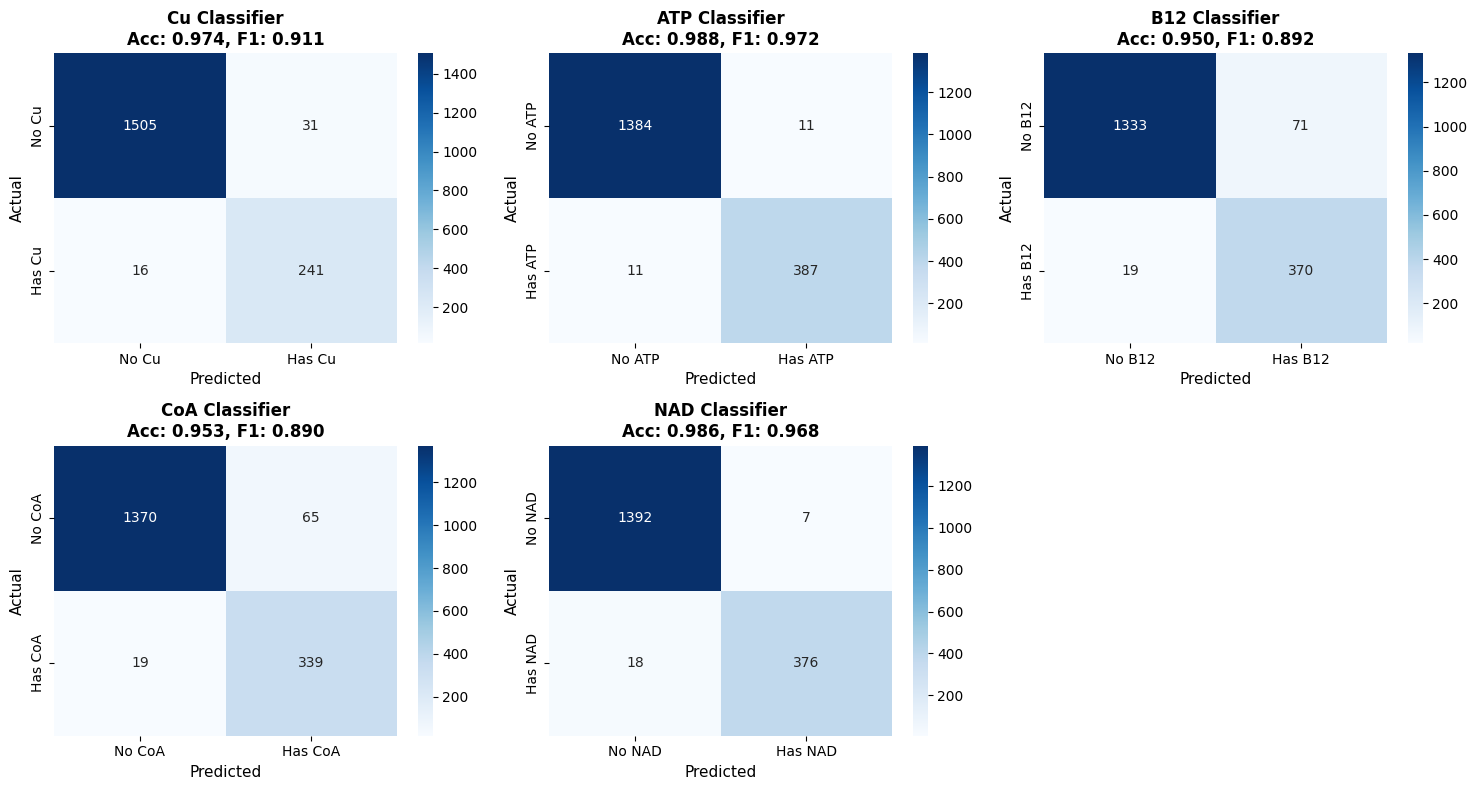


Confusion matrices for all 5 binary classifiers


In [75]:
# Generate confusion matrices for all binary classifiers

n_cofactors = len(cofactor_names)
n_cols = min(3, n_cofactors)
n_rows = int(np.ceil(n_cofactors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_cofactors == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, cofactor in enumerate(cofactor_names):
    results = binary_results[cofactor]
    cm = confusion_matrix(results['y_test'], results['y_pred'])
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'No {cofactor}', f'Has {cofactor}'],
        yticklabels=[f'No {cofactor}', f'Has {cofactor}'],
        ax=axes[idx],
        cbar=True
    )
    
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_title(f'{cofactor} Classifier\nAcc: {results["accuracy"]:.3f}, F1: {results["f1"]:.3f}', 
                       fontsize=12, fontweight='bold')

# Hide extra subplots if n_cofactors doesn't fill the grid
for idx in range(n_cofactors, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nConfusion matrices for all {len(cofactor_names)} binary classifiers")

## Feature Importance Analysis

Analyze which ESM2 embedding dimensions are most important for each cofactor classifier. Logistic regression coefficients indicate which features (embedding dimensions) contribute most to predictions.

In [76]:
# Extract and rank feature importance for each classifier

feature_importance_summary = {}

print("=" * 80)
print("TOP 20 MOST IMPORTANT FEATURES FOR EACH COFACTOR CLASSIFIER")
print("=" * 80)
print("\nNote: Features are ESM2 embedding dimensions (0-319)")
print("Positive coefficients indicate features that increase cofactor binding likelihood")
print("Negative coefficients indicate features that decrease cofactor binding likelihood\n")

for cofactor in cofactor_names:
    clf = binary_classifiers[cofactor]
    coefficients = clf.coef_[0]  # Shape: (320,)
    
    # Get absolute values for importance ranking
    abs_coefs = np.abs(coefficients)
    
    # Get top 20 features
    top_indices = np.argsort(abs_coefs)[-20:][::-1]
    top_values = coefficients[top_indices]
    
    feature_importance_summary[cofactor] = {
        'top_indices': top_indices,
        'top_values': top_values,
        'all_coefficients': coefficients
    }
    
    print(f"\n{cofactor} Classifier:")
    print("-" * 60)
    print(f"{'Rank':<6} {'Feature Dim':<15} {'Coefficient':<15} {'Impact'}")
    print("-" * 60)
    
    for rank, (idx, val) in enumerate(zip(top_indices, top_values), 1):
        impact = "Positive +" if val > 0 else "Negative -"
        print(f"{rank:<6} Dim {idx:<12} {val:>12.4f}    {impact}")
    
    # Summary statistics
    print("-" * 60)
    print(f"Mean |coefficient|: {np.mean(abs_coefs):.4f}")
    print(f"Max |coefficient|:  {np.max(abs_coefs):.4f}")
    print(f"Std coefficient:    {np.std(coefficients):.4f}")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("- Higher |coefficient| = more important for prediction")
print("- Positive coefficient = feature increases binding probability")
print("- Negative coefficient = feature decreases binding probability")
print("- ESM2 dimensions capture protein sequence patterns")
print("- Different cofactors rely on different sequence features")

TOP 20 MOST IMPORTANT FEATURES FOR EACH COFACTOR CLASSIFIER

Note: Features are ESM2 embedding dimensions (0-319)
Positive coefficients indicate features that increase cofactor binding likelihood
Negative coefficients indicate features that decrease cofactor binding likelihood


Cu Classifier:
------------------------------------------------------------
Rank   Feature Dim     Coefficient     Impact
------------------------------------------------------------
1      Dim 181               -1.3921    Negative -
2      Dim 126                1.2662    Positive +
3      Dim 248               -1.1707    Negative -
4      Dim 140                1.1532    Positive +
5      Dim 158                1.1434    Positive +
6      Dim 279                1.0591    Positive +
7      Dim 150               -1.0458    Negative -
8      Dim 303                1.0405    Positive +
9      Dim 272                1.0371    Positive +
10     Dim 241                1.0035    Positive +
11     Dim 166             

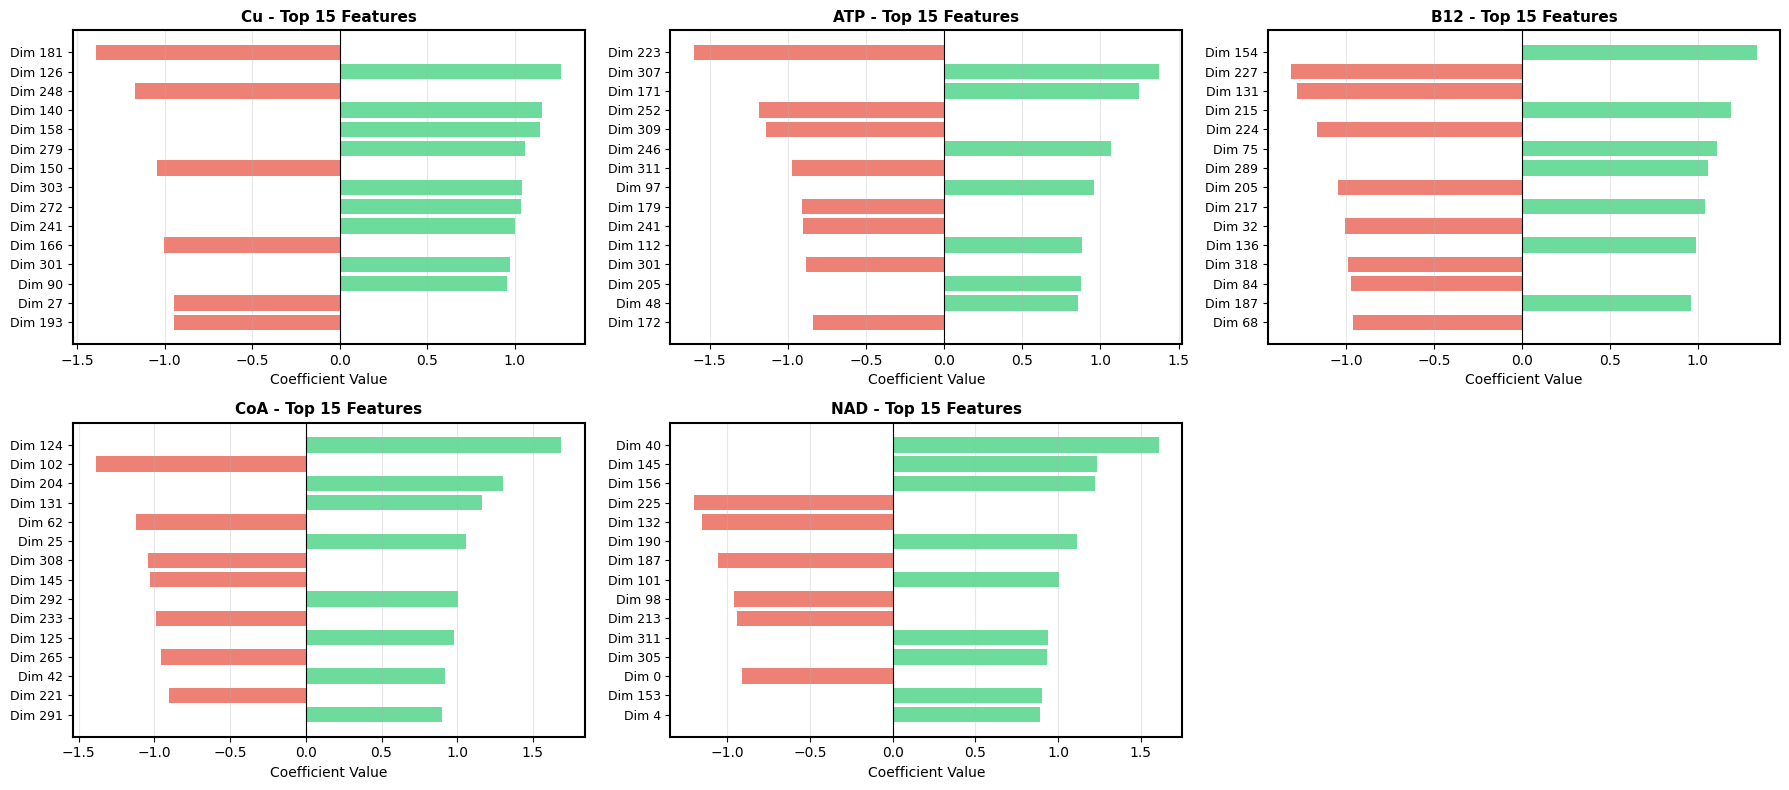


Feature importance visualization for 5 classifiers
Green bars: Positive coefficients (increase binding probability)
Red bars: Negative coefficients (decrease binding probability)


In [77]:
# Visualize feature importance for each classifier

n_cofactors = len(cofactor_names)
n_cols = min(3, n_cofactors)
n_rows = int(np.ceil(n_cofactors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
if n_cofactors == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, cofactor in enumerate(cofactor_names):
    importance = feature_importance_summary[cofactor]
    top_indices = importance['top_indices'][:15]  # Show top 15
    top_values = importance['top_values'][:15]
    
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_values]
    
    axes[idx].barh(range(len(top_indices)), top_values, color=colors, alpha=0.7)
    axes[idx].set_yticks(range(len(top_indices)))
    axes[idx].set_yticklabels([f'Dim {i}' for i in top_indices], fontsize=9)
    axes[idx].set_xlabel('Coefficient Value', fontsize=10)
    axes[idx].set_title(f'{cofactor} - Top 15 Features', fontsize=11, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[idx].grid(axis='x', alpha=0.3)
    
    # Invert y-axis so most important is on top
    axes[idx].invert_yaxis()

# Hide extra subplots
for idx in range(n_cofactors, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nFeature importance visualization for {len(cofactor_names)} classifiers")
print("Green bars: Positive coefficients (increase binding probability)")
print("Red bars: Negative coefficients (decrease binding probability)")

In [60]:
# Function to predict cofactors for new proteins using binary classifiers

def predict_cofactors_binary(sequence_embeddings, classifiers):
    predictions = {}
    
    for cofactor in cofactor_names:
        clf = classifiers[cofactor]
        y_pred = clf.predict(sequence_embeddings)
        y_proba = clf.predict_proba(sequence_embeddings)[:, 1]
        
        predictions[f'{cofactor}_prediction'] = y_pred
        predictions[f'{cofactor}_probability'] = y_proba
    
    return pd.DataFrame(predictions)

print("=== EXAMPLE PREDICTIONS ===\n")
test_indices = [0, 2, 4, 10, 15]
test_embeddings = X_seq[test_indices]

predictions_df = predict_cofactors_binary(test_embeddings, binary_classifiers)

predictions_df['protein_id'] = [df.iloc[i]['protein_id'][:40] for i in test_indices]
predictions_df['actual_cofactor'] = [df.iloc[i]['ideal_cofactor'] for i in test_indices]

cols = ['protein_id', 'actual_cofactor'] + [c for c in predictions_df.columns if c not in ['protein_id', 'actual_cofactor']]
predictions_df = predictions_df[cols]

print(predictions_df.to_string())

print("\nPredictions made using ONLY sequence information")
print("  No activity data used - realistic for novel proteins!")

=== EXAMPLE PREDICTIONS ===

                                 protein_id actual_cofactor  Cu_prediction  Cu_probability  ATP_prediction  ATP_probability  B12_prediction  B12_probability  CoA_prediction  CoA_probability  NAD_prediction  NAD_probability
0  NP_013752.1 copper chaperone CCS1 [Sacch              Cu              1        0.917691               0         0.102511               0         0.113632               0         0.192589               0         0.178793
1  WP_415607860.1 copper homeostasis protei              Cu              1        0.958491               0         0.040104               1         0.595378               0         0.003960               0         0.047972
2  CAN5492343.1 copper oxidase [soil metage              Cu              1        0.966324               0         0.013212               0         0.039521               0         0.031423               0         0.023128
3  NP_001004652.1 cytochrome c oxidase copp              Cu              1     

## Save Binary Classifiers

Save trained models and metadata for future use.

In [78]:
# Save binary classifiers to file for later use

import pickle

binary_artifacts = {
    'classifiers': binary_classifiers,
    'cofactor_names': cofactor_names,
    'feature_importance': feature_importance_summary,
    'esm_model_name': "esm2_t6_8M_UR50D",
    'embedding_dim': 320,
    'approach': 'binary_classification',
    'features_used': 'sequence_embeddings_only',
    'data_leakage': False,
    'performance': {cf: binary_results[cf]['accuracy'] for cf in cofactor_names}
}

output_path = r'C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\binary_cofactor_classifiers.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(binary_artifacts, f)

print(f"Saved binary classifiers to: {output_path}")
print("\nArtifacts include:")
print(f"  - {len(cofactor_names)} binary classifiers (one per cofactor)")
print(f"  - Cofactor names: {', '.join(cofactor_names)}")
print(f"  - Feature importance for each classifier")
print("  - ESM model info: esm2_t6_8M_UR50D")
print("  - Confirmed: No data leakage")
print("\nTo use on new proteins:")
print("  1. Generate ESM embeddings from sequence")
print("  2. Load classifiers with pickle.load()")
print("  3. Call predict() on each binary classifier")
print("  4. Get yes/no prediction + probability for each cofactor")

Saved binary classifiers to: C:\Users\d_gar\research\code_and_scripts\data_analysis\cofactor_PLM\binary_cofactor_classifiers.pkl

Artifacts include:
  - 5 binary classifiers (one per cofactor)
  - Cofactor names: Cu, ATP, B12, CoA, NAD
  - Feature importance for each classifier
  - ESM model info: esm2_t6_8M_UR50D
  - Confirmed: No data leakage

To use on new proteins:
  1. Generate ESM embeddings from sequence
  2. Load classifiers with pickle.load()
  3. Call predict() on each binary classifier
  4. Get yes/no prediction + probability for each cofactor
